/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_84255/1074705961.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])


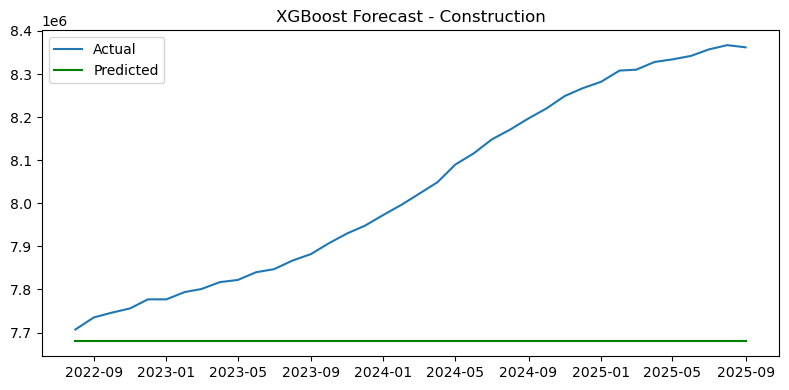

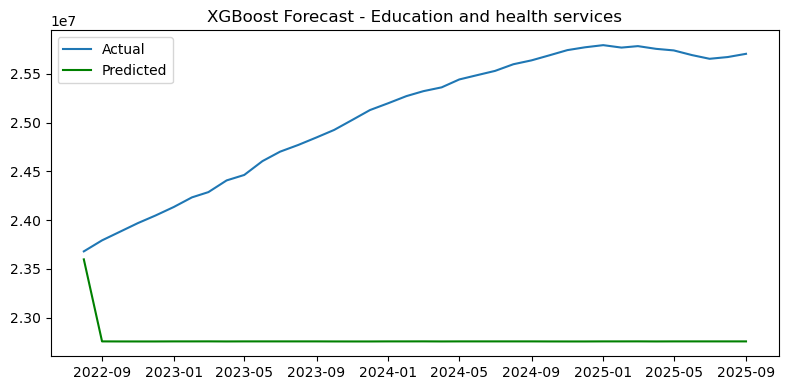

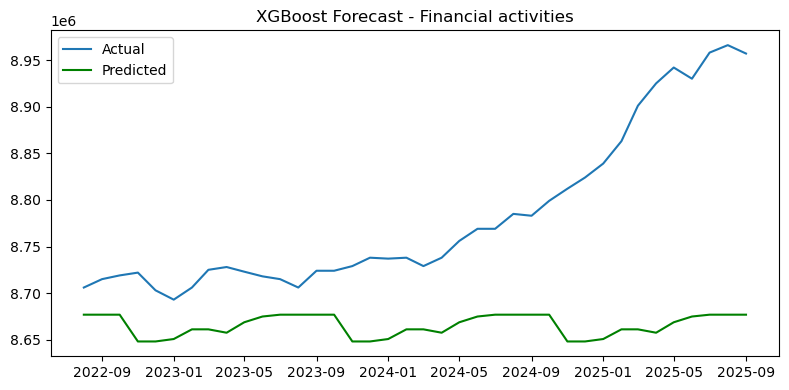

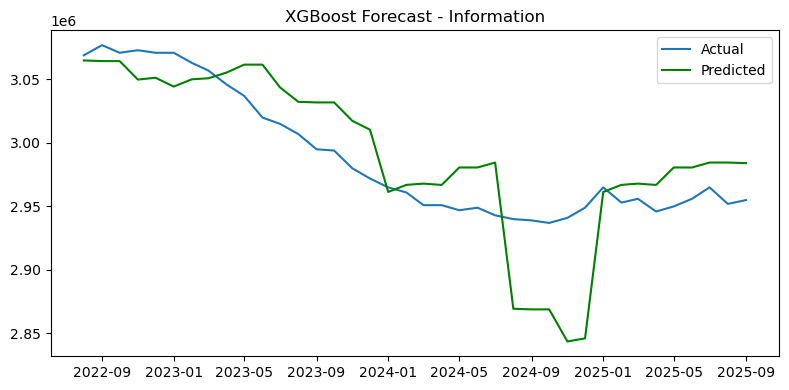

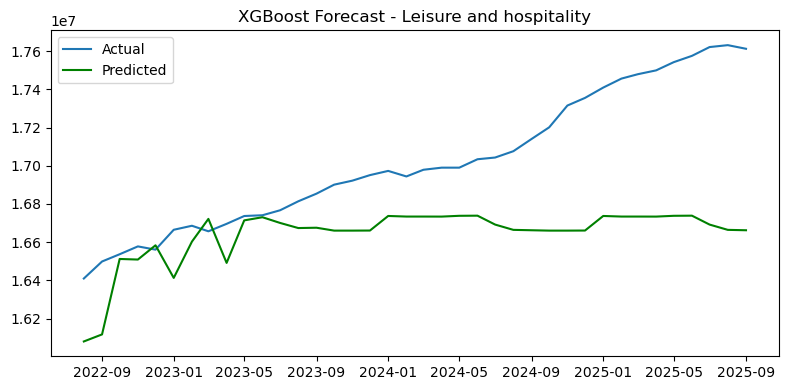

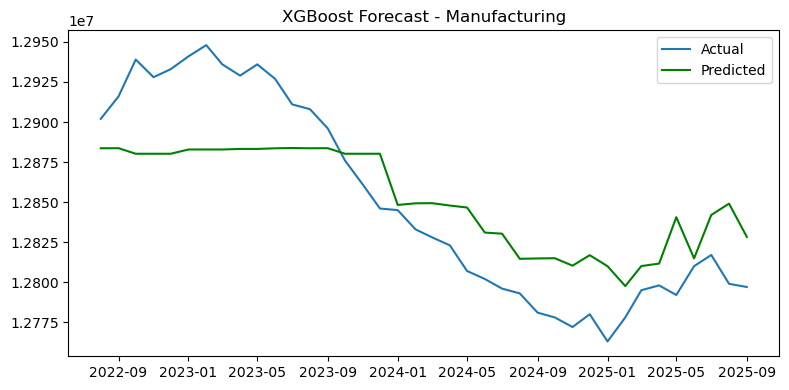

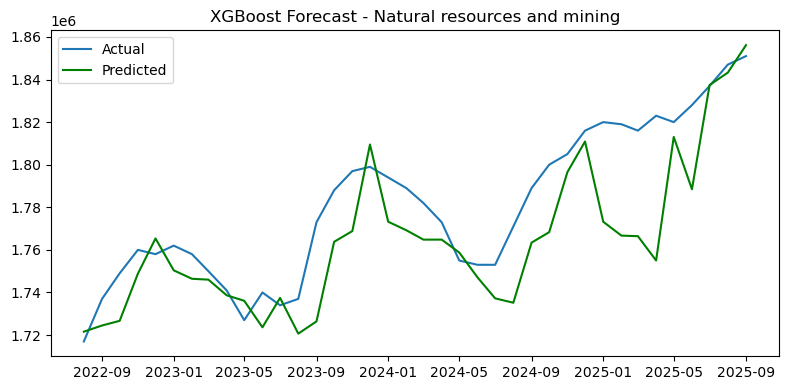

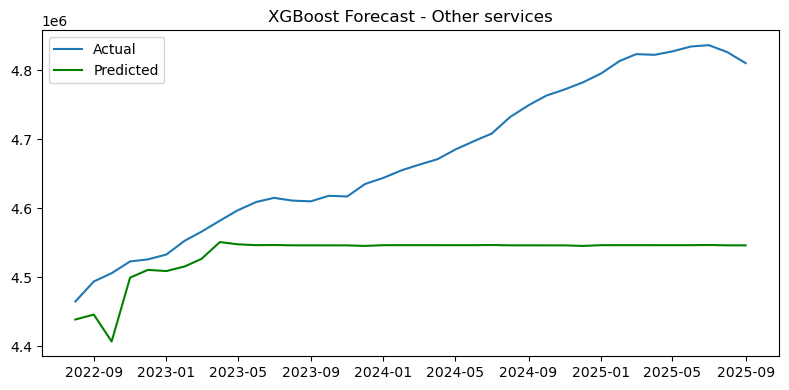

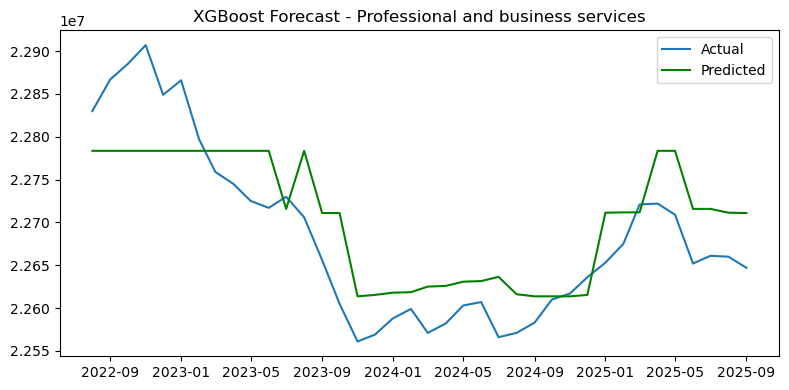

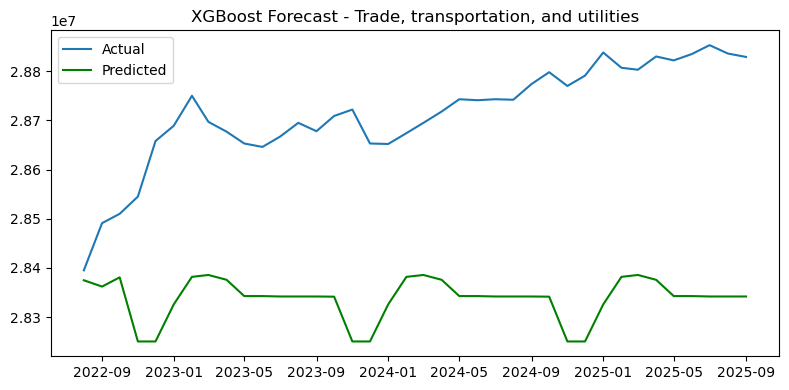

In [8]:
# --- Step 1: Import libraries ---
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# --- Step 2: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 3: Define function for lag feature creation ---
def create_lag_features(series, lags=2):
    df_temp = pd.DataFrame(series)
    for i in range(1, lags + 1):
        df_temp[f'lag_{i}'] = df_temp[series.name].shift(i)
    df_temp['year'] = df_temp.index.year
    df_temp['month'] = df_temp.index.month
    return df_temp.dropna()

# --- Step 4: Loop through industries ---
results = []

for industry in df.columns:
    data = create_lag_features(df[industry])
    X = data.drop(columns=[industry])
    y = data[industry]
    
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    try:
        model = XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)
        growth_rate = ((y_pred[-1] - y_train.iloc[-1]) / y_train.iloc[-1]) * 100
        
        results.append({
            'Industry': industry,
            'XGB_RMSE': rmse,
            'XGB_MAPE': mape,
            'XGB_Growth_%': growth_rate
        })
        
        # Optional: plot each industry
        plt.figure(figsize=(8,4))
        plt.plot(y_test.index, y_test, label='Actual')
        plt.plot(y_test.index, y_pred, label='Predicted', color='green')
        plt.title(f'XGBoost Forecast - {industry}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error fitting XGBoost for {industry}: {e}")


In [10]:
import pandas as pd

# --- Step 1: Convert results list to DataFrame ---
xgb_results_df = pd.DataFrame(results)

# --- Step 2: Define output file path in the current notebook folder ---
output_XG = 'xgboost_forecasts.csv'  # This will save in the same folder as your notebook

# --- Step 3: Save the file ---
xgb_results_df.to_csv(output_XG, index=False)
print(f'Results saved successfully to {output_XG}')

Results saved successfully to xgboost_forecasts.csv
